In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
#import scienceplots
import torch

# ==========================================
# 辅助函数
# ==========================================
def gaussian_pdf(x):
    if isinstance(x, torch.Tensor):
        return (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * x**2)
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

def generate_chirp_signal(Nx_total, f_start=0.005, f_end=0.05, amplitude=1.0):
    """
    生成线性调频信号 (Chirp Signal)
    在后半段时间幅值变为0.6倍
    """
    t = torch.arange(Nx_total, dtype=torch.float32)

    chirp_rate = (f_end - f_start) / Nx_total
    phase = 2 * np.pi * (f_start * t + 0.5 * chirp_rate * t**2)
    chirp_signal = amplitude * torch.sin(phase + np.pi)

    half_point = Nx_total // 2
    chirp_signal[half_point:] *= 0.6

    return chirp_signal.reshape(-1, 1)

# ==========================================
# EKF — 三组阵列
# N1=10, theta1=-0.8 | N2=11, theta2=0.0 | N3=10, theta3=0.8
# ==========================================
def run_chirp_tracking(input_signal, init_sigma,
                       N1=10, N2=11, N3=10,
                       theta1=-0.6, theta2=0.0, theta3=0.6,
                       seed_val=42, window_size=50):
    """
    使用三组阈值阵列跟踪Chirp信号
    权系数向量为 3 维: [w1, w2, w3]
    """
    torch.manual_seed(seed_val)
    np.random.seed(seed_val)

    Nx_total = input_signal.shape[0]

    # --- 初始化权系数向量和协方差 (3×1) ---
    W_vec = torch.tensor([[1.0], [1.0], [1.0]], dtype=torch.float32)
    P_rls = torch.eye(3) * 10.0

    # --- EKF 初始化 ---
    sigma_curr = init_sigma
    P_sigma = 2.0
    Q_sigma = 1e-4
    R_sigma = 1.0

    # --- 记录数组 ---
    sigma_history = torch.zeros(Nx_total)
    W1_history    = torch.zeros(Nx_total)
    W2_history    = torch.zeros(Nx_total)
    W3_history    = torch.zeros(Nx_total)
    H_k_history   = torch.zeros(Nx_total)

    instantaneous_error = torch.zeros(Nx_total)
    instantaneous_mse   = torch.zeros(Nx_total)
    windowed_mse        = torch.zeros(Nx_total)

    sigma_rate = torch.zeros(Nx_total)
    W1_rate    = torch.zeros(Nx_total)
    W2_rate    = torch.zeros(Nx_total)
    W3_rate    = torch.zeros(Nx_total)

    y_hat_history = torch.zeros(Nx_total)

    for k in range(Nx_total):
        x_k = input_signal[k, 0]

        # 1. 生成三组观测
        noise_std = max(sigma_curr, 0.01)

        torch.manual_seed(seed_val + k * 100)
        noise1 = noise_std * torch.randn(N1, 1)
        y1_vec = torch.sign(x_k + noise1 - theta1)
        phi1   = torch.mean(y1_vec)

        torch.manual_seed(seed_val + k * 200)
        noise2 = noise_std * torch.randn(N2, 1)
        y2_vec = torch.sign(x_k + noise2 - theta2)
        phi2   = torch.mean(y2_vec)

        torch.manual_seed(seed_val + k * 300)
        noise3 = noise_std * torch.randn(N3, 1)
        y3_vec = torch.sign(x_k + noise3 - theta3)
        phi3   = torch.mean(y3_vec)

        phi_vec = torch.tensor([[phi1], [phi2], [phi3]])  # 3×1

        # 2. Vector RLS 更新
        y_hat = torch.matmul(W_vec.T, phi_vec)   # 标量
        e_k   = x_k - y_hat

        numer = torch.matmul(P_rls, phi_vec)
        denom = torch.matmul(phi_vec.T, torch.matmul(P_rls, phi_vec)) + 0.1
        g_rls = numer / denom                     # 3×1

        W_vec_old = W_vec.clone()
        W_vec  = W_vec + g_rls * e_k
        P_rls  = P_rls - torch.matmul(g_rls, torch.matmul(phi_vec.T, P_rls))

        # 3. EKF 预测
        sigma_pred = sigma_curr
        P_pred     = P_sigma + Q_sigma

        # 4. 计算 Jacobian H_k（三组之和）
        s_safe = max(sigma_pred, 0.01)

        u1   = (x_k - theta1) / s_safe
        pdf1 = gaussian_pdf(u1)
        h1   = -2.0 * W_vec[0].item() * ((x_k - theta1) / s_safe**2) * pdf1

        u2   = (x_k - theta2) / s_safe
        pdf2 = gaussian_pdf(u2)
        h2   = -2.0 * W_vec[1].item() * ((x_k - theta2) / s_safe**2) * pdf2

        u3   = (x_k - theta3) / s_safe
        pdf3 = gaussian_pdf(u3)
        h3   = -2.0 * W_vec[2].item() * ((x_k - theta3) / s_safe**2) * pdf3

        H_k = h1 + h2 + h3

        # 5. EKF 更新
        S_innov = H_k**2 * P_pred + R_sigma
        K_sigma = P_pred * H_k / S_innov

        step    = K_sigma * e_k.item()
        step    = max(min(step, 0.5), -0.5)

        sigma_old = sigma_curr
        sigma_new = sigma_pred + step
        sigma_new = max(min(sigma_new, 5.0), 0.03)
        P_sigma   = (1 - K_sigma * H_k) * P_pred

        # 6. 记录
        sigma_history[k] = sigma_curr
        W1_history[k]    = W_vec[0].item()
        W2_history[k]    = W_vec[1].item()
        W3_history[k]    = W_vec[2].item()
        H_k_history[k]   = H_k
        y_hat_history[k] = y_hat.item()

        instantaneous_error[k] = e_k.item()
        instantaneous_mse[k]   = e_k.item()**2

        if k > 0:
            sigma_rate[k] = sigma_curr - sigma_old
            W1_rate[k]    = W_vec[0].item() - W_vec_old[0].item()
            W2_rate[k]    = W_vec[1].item() - W_vec_old[1].item()
            W3_rate[k]    = W_vec[2].item() - W_vec_old[2].item()

        if k < window_size:
            windowed_mse[k] = torch.mean(instantaneous_mse[:k+1]).item()
        else:
            windowed_mse[k] = torch.mean(
                instantaneous_mse[k-window_size+1:k+1]).item()

        sigma_curr = sigma_new

    return {
        'sigma_hist':  sigma_history.numpy(),
        'W1_hist':     W1_history.numpy(),
        'W2_hist':     W2_history.numpy(),
        'W3_hist':     W3_history.numpy(),
        'H_k_hist':    H_k_history.numpy(),
        'y_hat_hist':  y_hat_history.numpy(),
        'error_hist':  instantaneous_error.numpy(),
        'mse_hist':    windowed_mse.numpy(),
        'sigma_rate':  sigma_rate.numpy(),
        'W1_rate':     W1_rate.numpy(),
        'W2_rate':     W2_rate.numpy(),
        'W3_rate':     W3_rate.numpy(),
        'input_signal': input_signal.squeeze().numpy()
    }

def compute_tracking_metrics(results, transition_point=1500, steady_window=300):
    """计算跟踪性能指标 - 分段版本"""
    Nx_total = len(results['error_hist'])
    metrics  = {}

    segment1_start = max(0, transition_point - steady_window - 200)
    segment1_end   = transition_point - 50
    segment2_start = transition_point + 200
    segment2_end   = min(Nx_total, transition_point + steady_window + 200)

    metrics['segment1'] = {
        'start':      segment1_start,
        'end':        segment1_end,
        'sigma_mean': np.mean(results['sigma_hist'][segment1_start:segment1_end]),
        'sigma_std':  np.std( results['sigma_hist'][segment1_start:segment1_end]),
        'W1_mean':    np.mean(results['W1_hist'][segment1_start:segment1_end]),
        'W2_mean':    np.mean(results['W2_hist'][segment1_start:segment1_end]),
        'W3_mean':    np.mean(results['W3_hist'][segment1_start:segment1_end]),
        'mse_mean':   np.mean(results['mse_hist'][segment1_start:segment1_end])
    }

    metrics['segment2'] = {
        'start':      segment2_start,
        'end':        segment2_end,
        'sigma_mean': np.mean(results['sigma_hist'][segment2_start:segment2_end]),
        'sigma_std':  np.std( results['sigma_hist'][segment2_start:segment2_end]),
        'W1_mean':    np.mean(results['W1_hist'][segment2_start:segment2_end]),
        'W2_mean':    np.mean(results['W2_hist'][segment2_start:segment2_end]),
        'W3_mean':    np.mean(results['W3_hist'][segment2_start:segment2_end]),
        'mse_mean':   np.mean(results['mse_hist'][segment2_start:segment2_end])
    }

    metrics['sigma_change'] = (metrics['segment2']['sigma_mean']
                               - metrics['segment1']['sigma_mean'])
    metrics['W1_change']    = (metrics['segment2']['W1_mean']
                               - metrics['segment1']['W1_mean'])
    metrics['W2_change']    = (metrics['segment2']['W2_mean']
                               - metrics['segment1']['W2_mean'])
    metrics['W3_change']    = (metrics['segment2']['W3_mean']
                               - metrics['segment1']['W3_mean'])

    window = 100
    error_envelope = np.zeros(Nx_total)
    for i in range(Nx_total):
        start = max(0, i - window)
        error_envelope[i] = np.std(results['error_hist'][start:i+1])
    metrics['error_envelope'] = error_envelope

    metrics['sigma_rate_rms'] = np.sqrt(np.mean(results['sigma_rate'][100:]**2))
    metrics['W1_rate_rms']    = np.sqrt(np.mean(results['W1_rate'][100:]**2))
    metrics['W2_rate_rms']    = np.sqrt(np.mean(results['W2_rate'][100:]**2))
    metrics['W3_rate_rms']    = np.sqrt(np.mean(results['W3_rate'][100:]**2))

    steady_mse_seg2 = metrics['segment2']['mse_mean']
    threshold       = 1.1 * steady_mse_seg2
    L_confirm       = 50
    convergence_time = Nx_total - transition_point

    for k in range(transition_point, Nx_total - L_confirm):
        if np.all(results['mse_hist'][k:k+L_confirm] < threshold):
            convergence_time = k - transition_point
            break

    metrics['convergence_time_segment2'] = convergence_time
    return metrics

# ==========================================
# 主程序
# ==========================================
# 三组阵列参数
N1, theta1 = 10, -0.7
N2, theta2 = 11,  0.0
N3, theta3 = 10,  0.7

print("="*80)
print("CHIRP SIGNAL TRACKING — THREE-GROUP SSR ARRAY (N=31)")
print(f"  Group 1: N1={N1}, theta1={theta1}")
print(f"  Group 2: N2={N2}, theta2={theta2}")
print(f"  Group 3: N3={N3}, theta3={theta3}")
print("="*80)

Nx_total   = 3000
f_start    = 0.005
f_end      = 0.05
amplitude  = 1.0
init_sigma = 1.0
seed_val   = 42



chirp_signal     = generate_chirp_signal(Nx_total, f_start, f_end, amplitude)
half_point       = Nx_total // 2
transition_point = half_point

results = run_chirp_tracking(chirp_signal, init_sigma,
                             N1=N1, N2=N2, N3=N3,
                             theta1=theta1, theta2=theta2, theta3=theta3,
                             seed_val=seed_val)
metrics = compute_tracking_metrics(results,
                                   transition_point=transition_point,
                                   steady_window=300)

print(f"\n=== SEGMENT 1 (k=[{metrics['segment1']['start']}, {metrics['segment1']['end']}]) ===")
print(f"   sigma: {metrics['segment1']['sigma_mean']:.4f} ± {metrics['segment1']['sigma_std']:.4f}")
print(f"   w1: {metrics['segment1']['W1_mean']:.4f}  w2: {metrics['segment1']['W2_mean']:.4f}  w3: {metrics['segment1']['W3_mean']:.4f}")
print(f"   MSE: {metrics['segment1']['mse_mean']:.6f}")

print(f"\n=== SEGMENT 2 (k=[{metrics['segment2']['start']}, {metrics['segment2']['end']}]) ===")
print(f"   sigma: {metrics['segment2']['sigma_mean']:.4f} ± {metrics['segment2']['sigma_std']:.4f}")
print(f"   w1: {metrics['segment2']['W1_mean']:.4f}  w2: {metrics['segment2']['W2_mean']:.4f}  w3: {metrics['segment2']['W3_mean']:.4f}")
print(f"   MSE: {metrics['segment2']['mse_mean']:.6f}")

print(f"\n=== PARAMETER CHANGES ===")
print(f"   Delta_sigma: {metrics['sigma_change']:+.4f}  ({metrics['sigma_change']/metrics['segment1']['sigma_mean']*100:+.1f}%)")
print(f"   Delta_w1:    {metrics['W1_change']:+.4f}")
print(f"   Delta_w2:    {metrics['W2_change']:+.4f}")
print(f"   Delta_w3:    {metrics['W3_change']:+.4f}")
print(f"\n   Re-convergence time: {metrics['convergence_time_segment2']} samples")

tracking_results = {
    'results':       results,
    'metrics':       metrics,
    'signal_params': {
        'Nx_total':         Nx_total,
        'f_start':          f_start,
        'f_end':            f_end,
        'amplitude':        amplitude,
        'transition_point': transition_point
    }
}

CHIRP SIGNAL TRACKING — THREE-GROUP SSR ARRAY (N=31)
  Group 1: N1=10, theta1=-0.7
  Group 2: N2=11, theta2=0.0
  Group 3: N3=10, theta3=0.7

=== SEGMENT 1 (k=[1000, 1450]) ===
   sigma: 0.2120 ± 0.0030
   w1: 0.3074  w2: 0.3735  w3: 0.3093
   MSE: 0.007226

=== SEGMENT 2 (k=[1700, 2000]) ===
   sigma: 0.2725 ± 0.0080
   w1: 0.3098  w2: 0.3712  w3: 0.3098
   MSE: 0.009610

=== PARAMETER CHANGES ===
   Delta_sigma: +0.0604  (+28.5%)
   Delta_w1:    +0.0024
   Delta_w2:    -0.0023
   Delta_w3:    +0.0006

   Re-convergence time: 0 samples


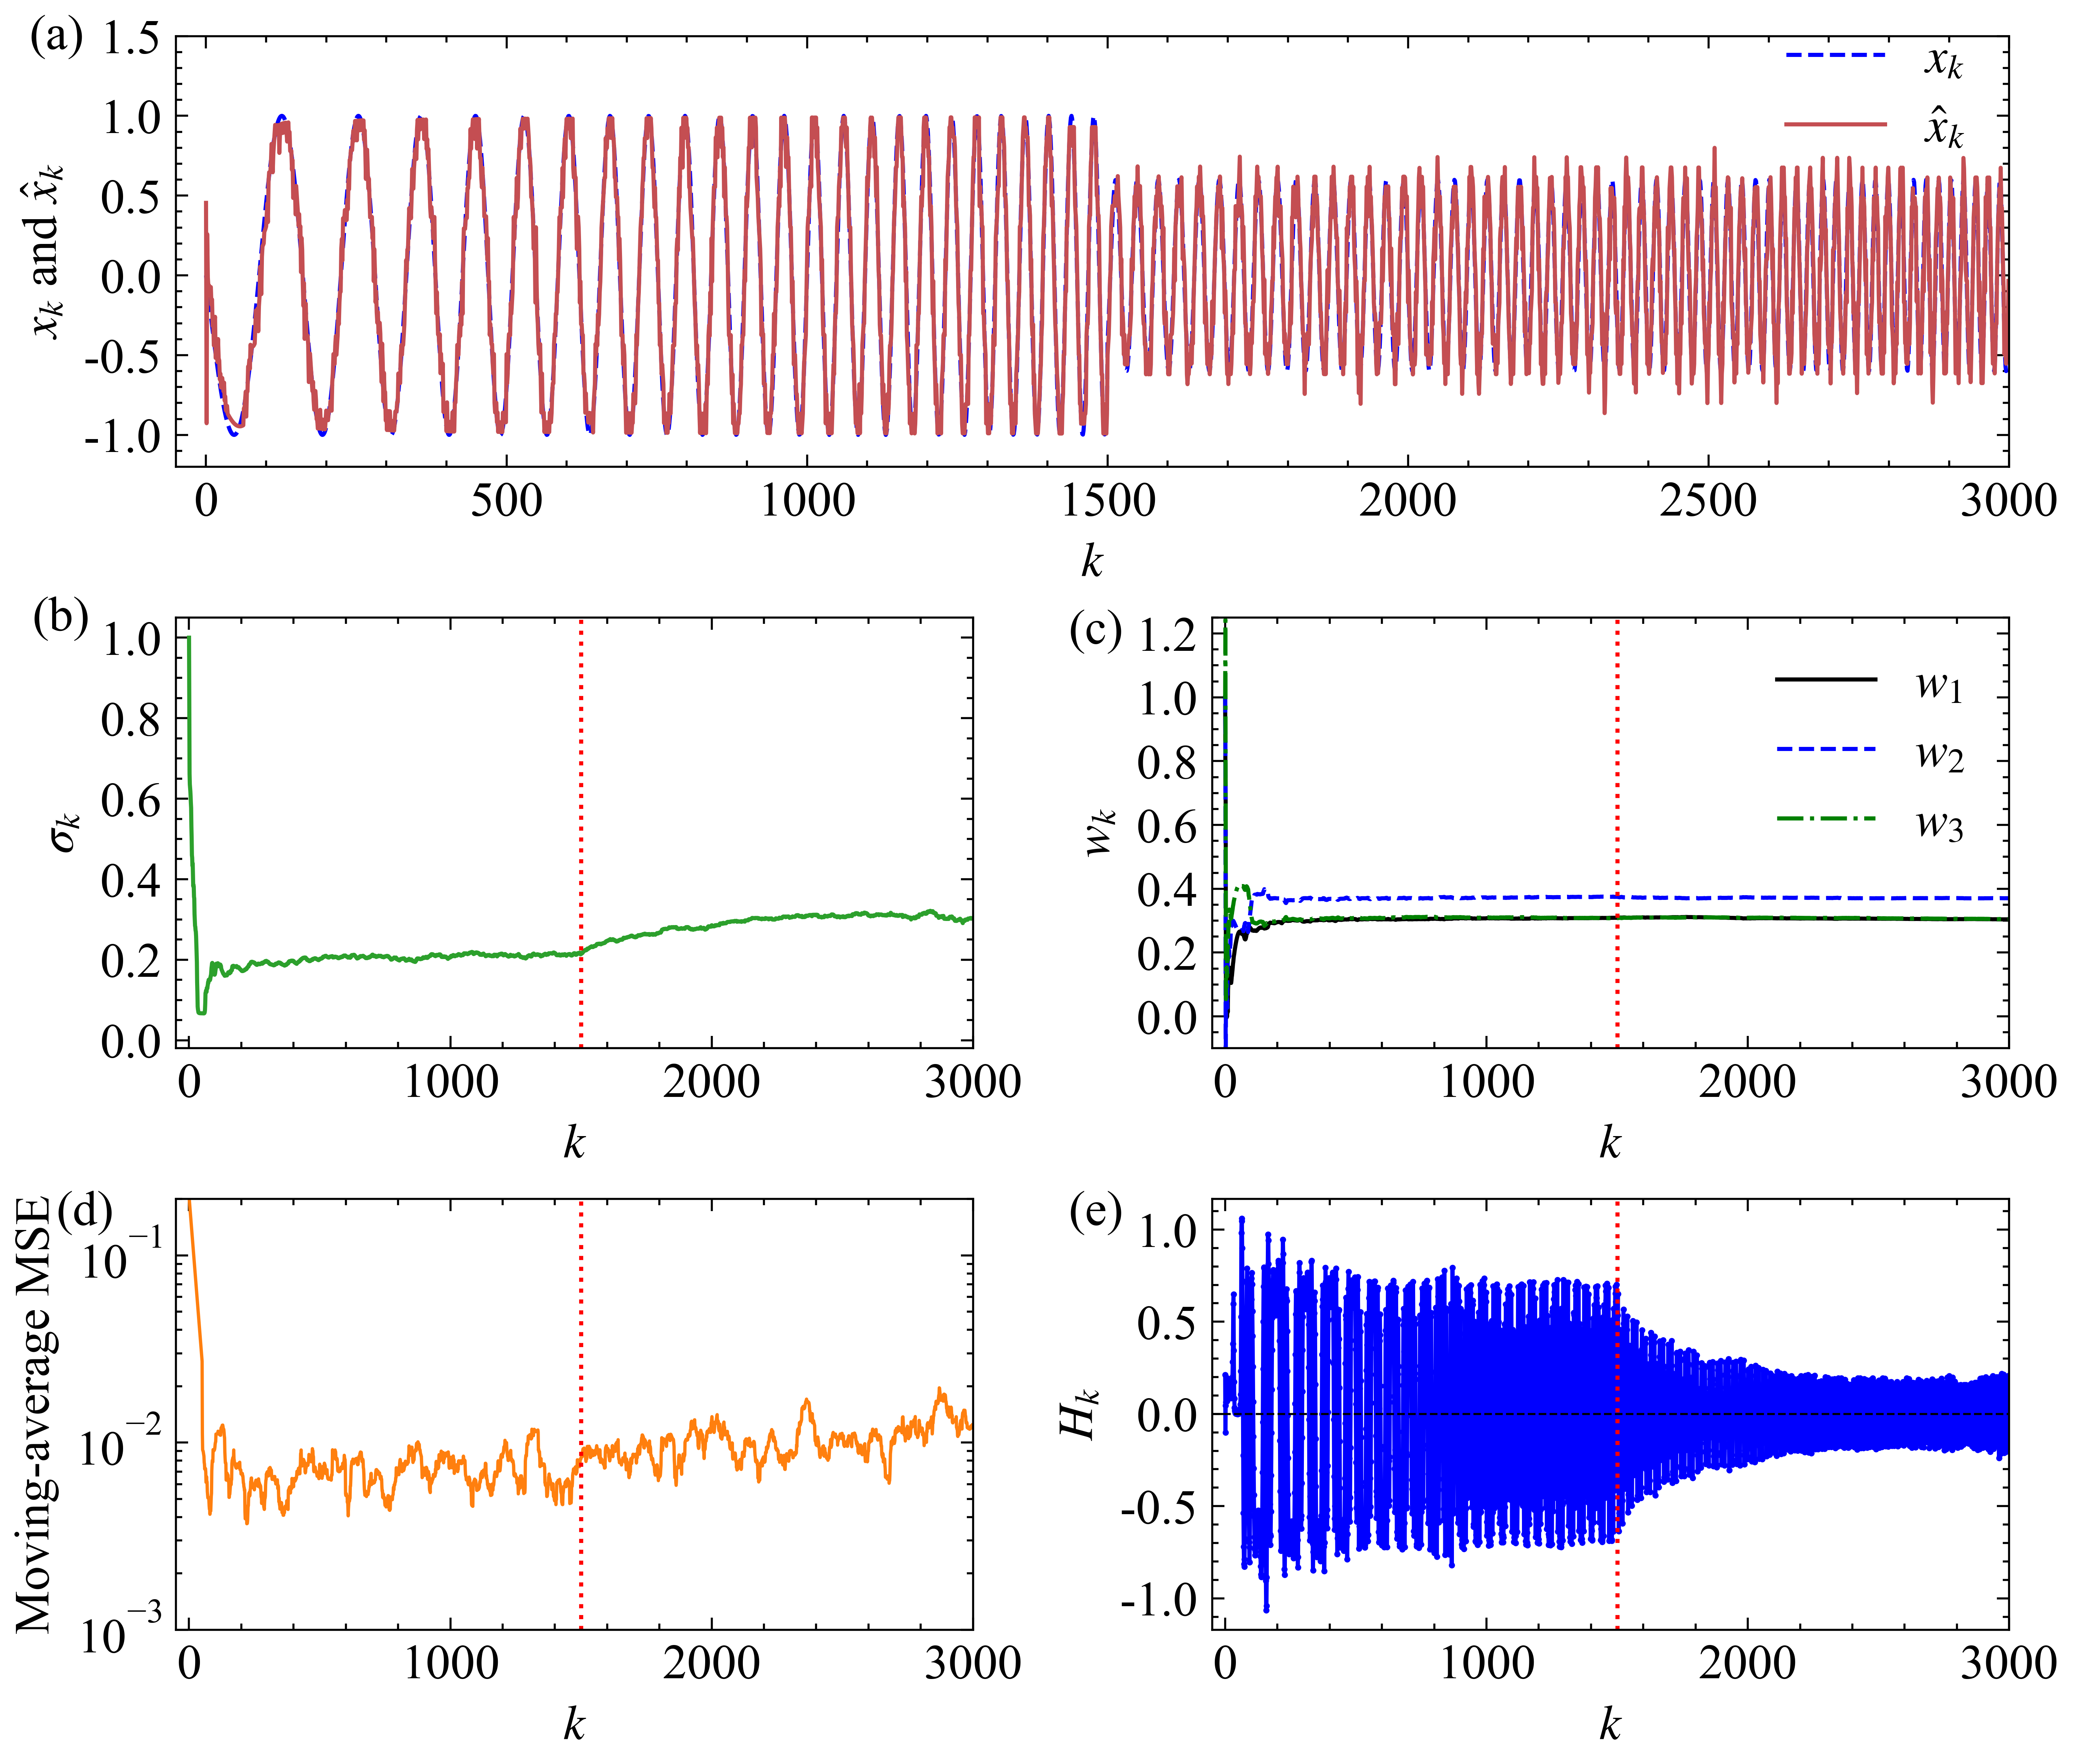

In [17]:
# ==========================================
# 绘图
# ==========================================
from matplotlib.ticker import ScalarFormatter
import colorsys
from matplotlib.ticker import MultipleLocator

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams.update({
    'font.family':      'serif',
    'font.serif':       ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size':        12,
    'axes.labelsize':   12,
    'legend.fontsize':  12,
})
mpl.rcParams['text.usetex']        = False
mpl.rcParams['axes.unicode_minus'] = False

results          = tracking_results['results']
metrics          = tracking_results['metrics']
Nx_total         = tracking_results['signal_params']['Nx_total']
transition_point = tracking_results['signal_params']['transition_point']
iterations       = np.arange(Nx_total)

color_signal   = '#1f77b4'
color_tracking = '#c44e52'
color_error    = '#ff7f0e'
color_sigma    = '#2ca02c'

fig = plt.figure(figsize=(8, 7))
gs  = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.30)

axes = [
    fig.add_subplot(gs[0, :]),   # (a) 信号跟踪
    fig.add_subplot(gs[1, 0]),   # (b) sigma
    fig.add_subplot(gs[1, 1]),   # (c) weights
    fig.add_subplot(gs[2, 0]),   # (d) MSE
    fig.add_subplot(gs[2, 1]),   # (e) H_k
]
labels_txt = ['(a)', '(b)', '(c)', '(d)', '(e)']

# --- (a) 信号跟踪 ---
ax1 = axes[0]
ax1.plot(iterations, results['input_signal'],
         color='b', linewidth=1.0, linestyle='--', label=r'$x_k$')
ax1.plot(iterations, results['y_hat_hist'],
         color=color_tracking, linewidth=1.0, linestyle='-', label=r'$\hat{x}_k$')
ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.1), fontsize=12)
ax1.set_xlabel(r'$k$')
ax1.set_ylabel(r'$x_k$ and $\hat{x}_k$')
ax1.set_xlim(-50, Nx_total)
ax1.set_ylim(-1.2, 1.5)
ax1.yaxis.set_major_locator(MultipleLocator(0.5))
ax1.text(-0.08, 1.05, labels_txt[0], transform=ax1.transAxes, fontsize=12, va='top')

# --- (b) sigma ---
ax2 = axes[1]
ax2.plot(iterations, results['sigma_hist'], color=color_sigma, linewidth=1.0)
ax2.axvline(transition_point, color='red', linestyle=':', linewidth=1.0)
ax2.set_xlabel(r'$k$')
ax2.set_ylabel(r'$\sigma_k$')
ax2.set_xlim(-50, Nx_total)
ax2.set_ylim(-0.02, 1.05)
ax2.yaxis.set_major_locator(MultipleLocator(0.2))
ax2.text(-0.18, 1.05, labels_txt[1], transform=ax2.transAxes, fontsize=12, va='top')

# --- (c) 三个权系数 ---
ax3 = axes[2]
W1_plot = np.concatenate(([1.0], results['W1_hist']))
W2_plot = np.concatenate(([1.0], results['W2_hist']))
W3_plot = np.concatenate(([1.0], results['W3_hist']))
iter_plot = np.arange(len(W1_plot))

ax3.plot(iter_plot, W1_plot, color='k',  linewidth=1.0, linestyle='-',  label=r'$w_1$')
ax3.plot(iter_plot, W2_plot, color='b',  linewidth=1.0, linestyle='--', label=r'$w_2$')
ax3.plot(iter_plot, W3_plot, color='g',  linewidth=1.0, linestyle='-.',  label=r'$w_3$')
ax3.axvline(transition_point, color='red', linestyle=':', linewidth=1.0)
ax3.legend(loc='upper right', fontsize=12)
ax3.set_xlabel(r'$k$')
ax3.set_ylabel(r'$w_k$')
ax3.set_xlim(-50, Nx_total)
ax3.set_ylim(-0.1, 1.25)
ax3.yaxis.set_major_locator(MultipleLocator(0.2))
ax3.text(-0.18, 1.02, labels_txt[2], transform=ax3.transAxes, fontsize=12, va='top')

# --- (d) 滑动平均 MSE（对数坐标）---
ax4    = axes[3]
sq_err = results['error_hist'] ** 2
window = 50
sq_err_smooth = np.convolve(sq_err[1:], np.ones(window)/window, mode='valid')
sq_err_plot   = np.concatenate(([sq_err[0]], sq_err_smooth))
iter_d        = np.concatenate(([iterations[0]], iterations[1 + window - 1:]))

ax4.plot(iter_d, sq_err_plot, color=color_error, linewidth=0.8)
ax4.axvline(transition_point, color='red', linestyle=':', linewidth=1.0)
ax4.set_xlabel(r'$k$')
ax4.set_ylabel(r'Moving-average MSE', fontsize=12)
ax4.set_xlim(-50, Nx_total)
ax4.set_yscale('log')
ax4.set_ylim(1e-3, 0.2)
ax4.text(-0.15, 1.02, labels_txt[3], transform=ax4.transAxes, fontsize=12, va='top')

# --- (e) Jacobian H_k ---
ax5 = axes[4]
ax5.plot(iterations, results['H_k_hist'],
         marker='.', markersize=1.0, color='blue')
ax5.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax5.axvline(transition_point, color='red', linestyle=':', linewidth=1.0)
ax5.set_xlabel(r'$k$')
ax5.set_ylabel(r'$H_k$', fontsize=12)
ax5.set_xlim(-50, Nx_total)
ax5.set_yticks([-1, -0.5, 0, 0.5, 1])
ax5.text(-0.18, 1.02, labels_txt[4], transform=ax5.transAxes, fontsize=12, va='top')

plt.savefig('D:/IEEE 2025 Adaptive weighted SSR/Fig11.eps', format='eps', dpi=800)
plt.show()